In [2]:
#Cell 1
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
from IPython.display import FileLink, display
# Synthetic 2D datasets

def generate_gaussian_clusters(rng, n=2000, centers=4, std=0.1):
    cluster_centers = np.array([[1, 1], [1, -1], [-1, 1], [-1, -1]]) * 2.5
    data = []
    for center in cluster_centers[:centers]:
        cluster_data = center + std * rng.standard_normal(size=(n // centers, 2))
        data.append(cluster_data)
    return np.vstack(data), "Gaussian Clusters"

def generate_noisy_moons(n):
    data, _ = datasets.make_moons(n_samples=n, noise=0.05, random_state=seed)
    return data, "Noisy Moons"

In [3]:
#Cell2
seed = 42
rng = np.random.default_rng(seed=seed)
n = 2000

# NOTE: choose which dataset you want to load (by uncommenting one of the two lines)

# Case 1) Gaussian Clusters
# data, title = generate_gaussian_clusters(rng, n)

# Case 2) Noisy Moons
data, title = generate_noisy_moons(n)

X = torch.from_numpy(data).float() # to tensor format

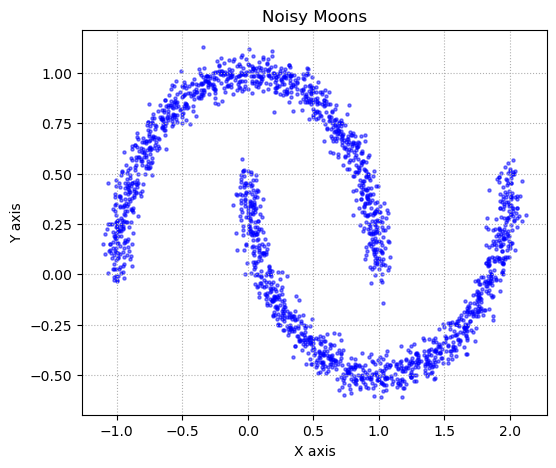

C:\Users\areft\Downloads\dataset_Noisy Moons.png

In [4]:
#Cell3
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(data[:, 0], data[:, 1], s=5, c='blue', alpha=0.5)
ax.set_title(title)
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.grid(True, ls=':')
plt.savefig(f"dataset_{title}.png")
plt.show()
display(FileLink(f"dataset_{title}.png"))

In [5]:
#Cell4
class Encoder(nn.Module):
    def __init__(self, x_dim, h_dim, z_dim):
        super().__init__()
        self.fc = nn.Linear(x_dim, h_dim)
        self.act = nn.ReLU()
        self.mu = nn.Linear(h_dim, z_dim)
        self.logvar = nn.Linear(h_dim, z_dim)
    
    def forward(self, x):
        h = self.act(self.fc(x))
        return self.mu(h), self.logvar(h)

class Decoder(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim):
        super().__init__()
        self.fc = nn.Linear(z_dim, h_dim)
        self.act = nn.ReLU()
        self.out = nn.Linear(h_dim, x_dim)
    
    def forward(self, z):
        h = self.act(self.fc(z))
        return self.out(h)

class BetaVAE(nn.Module):
    def __init__(self, x_dim, h_dim, z_dim, beta):
        super().__init__()
        self.encoder = Encoder(x_dim, h_dim, z_dim)
        self.decoder = Decoder(z_dim, h_dim, x_dim)
        self.beta = beta
    
    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar, z
    
    def loss(self, x, recon, mu, logvar):
        recon_loss = nn.MSELoss()(recon, x)
        kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + self.beta * kld, recon_loss, kld

def train_vae(vae, X, epochs=100, lr=1e-2):
    optimizer = optim.AdamW(vae.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        vae.train()
        recon, mu, logvar, z = vae(X)
        loss, recon_loss, kld = vae.loss(X, recon, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append((loss.item(), recon_loss.item(), kld.item()))
    return losses

In [6]:
#Cell5
# "[Kingma et al. (2016)](https://arxiv.org/pdf/1606.04934) proposes Free-Bits replacing the KL term with a hinge loss term. 
# It stops optimization of the KL value when it is smaller than a threshold."
# NOTE: Only experiment with this value after discussion
class BetaVAE_Bits(BetaVAE):
    def __init__(self, x_dim=2, h_dim=16, z_dim=2, beta=4.0, free_bits=0.5):
        super().__init__(x_dim, h_dim, z_dim, beta)
        self.free_bits = free_bits

    def loss(self, x, recon, mu, logvar):
        recon_loss = nn.MSELoss()(recon, x)
        kld_element = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kld = torch.clamp(kld_element, min=self.free_bits).mean()
        return recon_loss + self.beta * kld, recon_loss, kld

In [7]:
#Cell6
# Parameters
latent_dim = 2
hidden_dim = 8
epochs = 6000
learning_rate = 2.5e-3
beta_low = 0.001
beta_std = 1.0
beta_high= 4.0
nsamples = 2000 # used after training

In [8]:
#Cell7
# Train low beta (close to 0)
torch.manual_seed(seed+1) # fix RNG
vae_low_beta = BetaVAE(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta_low)
losses_low = train_vae(vae_low_beta, X, epochs=epochs, lr=learning_rate)
print("> vae low beta=0.001: training complete.")

# beta=1.0
torch.manual_seed(seed+2) # fix RNG
vae_std_beta = BetaVAE(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta_std)
losses_std = train_vae(vae_std_beta, X, epochs=epochs, lr=learning_rate)
print("> vae std beta=1.0: training complete.")

# Train high beta (>1)
torch.manual_seed(seed+3) # fix RNG
vae_high_beta = BetaVAE(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta_high)
losses_high = train_vae(vae_high_beta, X, epochs=epochs, lr=learning_rate)
print("> vae high beta=4.0: training complete.")

> vae low beta=0.001: training complete.
> vae std beta=1.0: training complete.
> vae high beta=4.0: training complete.


In [9]:
#Cell8
print(f"Final KLD (Low Beta=0.001): {losses_low[-1][2]:.4f}")
print(f"Final KLD (Std Beta=1.0): {losses_std[-1][2]:.4f}")
print(f"Final KLD (High Beta=4.0): {losses_high[-1][2]:.4f}")

Final KLD (Low Beta=0.001): 3.3727
Final KLD (Std Beta=1.0): 0.1339
Final KLD (High Beta=4.0): 0.0000


In [10]:
#Cll9
# training  free-bits Beta-VAE

# Train low beta (close to 0)
torch.manual_seed(seed+1) # fix RNG
vae_low_beta_opt = BetaVAE_Bits(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta_low)
losses_low_opt = train_vae(vae_low_beta_opt, X, epochs=epochs, lr=learning_rate)
print("> vae low beta=0.001: training complete.")

# beta=1.0
torch.manual_seed(seed+2) # fix RNG
vae_std_beta_opt = BetaVAE_Bits(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta_std)
losses_std_opt = train_vae(vae_std_beta_opt, X, epochs=epochs, lr=learning_rate)
print("> vae std beta=1.0: training complete.")

# Train high beta (>1)
torch.manual_seed(seed+3) # fix RNG
vae_high_beta_opt = BetaVAE_Bits(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta_high)
losses_high_opt = train_vae(vae_high_beta_opt, X, epochs=epochs, lr=learning_rate)
print("> vae high beta=4.0: training complete.")

> vae low beta=0.001: training complete.
> vae std beta=1.0: training complete.
> vae high beta=4.0: training complete.


In [11]:
#Cell10
print(f"Final KLD (Low Beta, FreeBits): {losses_low_opt[-1][2]:.4f}")
print(f"Final KLD (Std Beta, FreeBits): {losses_std_opt[-1][2]:.4f}")
print(f"Final KLD (High Beta, FreeBits): {losses_high_opt[-1][2]:.4f}")

Final KLD (Low Beta, FreeBits): 3.3726
Final KLD (Std Beta, FreeBits): 0.5033
Final KLD (High Beta, FreeBits): 0.5004


In [12]:
#Cell11
# Reconstruction plots: original vs reconstructions for low and high beta
with torch.no_grad():
    recon_low, mu_low, logvar_low, z_low = vae_low_beta(X)
    recon_std, mu_std, logvar_std, z_std = vae_std_beta(X)
    recon_high, mu_high, logvar_high, z_high = vae_high_beta(X)
    #
    recon_low_opt, mu_low_opt, logvar_low_opt, z_low_opt = vae_low_beta_opt(X)
    recon_std_opt, mu_std_opt, logvar_std_opt, z_std_opt = vae_std_beta_opt(X)
    recon_high_opt, mu_high_opt, logvar_high_opt, z_high_opt = vae_high_beta_opt(X)

recon_low_np = recon_low.numpy()
recon_std_np = recon_std.numpy()
recon_high_np = recon_high.numpy()
#
recon_low_np_opt = recon_low_opt.numpy()
recon_std_np_opt = recon_std_opt.numpy()
recon_high_np_opt = recon_high_opt.numpy()

# posterior means
mu_low = mu_low.numpy()
mu_std = mu_std.numpy()
mu_high = mu_high.numpy()
#
mu_low_opt = mu_low_opt.numpy()
mu_std_opt = mu_std_opt.numpy()
mu_high_opt = mu_high_opt.numpy()

torch.manual_seed(seed+10) 
# Sampling from latent space to data space
with torch.no_grad():
    z_samples = torch.randn(nsamples, latent_dim)
    gen_low = vae_low_beta.decoder(z_samples).numpy()
    gen_std = vae_std_beta.decoder(z_samples).numpy()
    gen_high = vae_high_beta.decoder(z_samples).numpy()
    #
    gen_low_opt = vae_low_beta_opt.decoder(z_samples).numpy()
    gen_std_opt = vae_std_beta_opt.decoder(z_samples).numpy()
    gen_high_opt = vae_high_beta_opt.decoder(z_samples).numpy()

# β-VAE Evaluation & Visualization Cells

All following 6 sections:
1. Prior vs Posterior — 5 β values
2. Reconstruction vs Original — 10 β values
3. Posterior Collapse Illustration — 3 β values
4. Evaluation metrics vs β — 10 β values
5. Extended β Sweep Collapse Analysis
6. Training Loss Curves (Standard vs Free-Bits)

---
## Helper: fix logvar numpy (not converted in Cell 11)

In [13]:
#Cell12
# logvar tensors were not .numpy()'d in Cell 11 — fix here
logvar_low  = logvar_low.numpy()
logvar_std  = logvar_std.numpy()
logvar_high = logvar_high.numpy()
logvar_low_opt  = logvar_low_opt.numpy()
logvar_std_opt  = logvar_std_opt.numpy()
logvar_high_opt = logvar_high_opt.numpy()

# z tensors to numpy
z_low_np  = z_low.numpy()
z_std_np  = z_std.numpy()
z_high_np = z_high.numpy()

# Consistent plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.5,
})
print("Setup complete.")

Setup complete.


---
## Section 1 — Prior vs Posterior in Latent Space (5 β values)

We train 5 models at β ∈ {0.001, 0.1, 1, 4, 16} and visualise:
- **Dots** = posterior means μ(x) for each data point
- **Red dashed circle** = 2-σ contour of the standard Gaussian prior N(0, I)

As β grows the posterior is squeezed toward the prior.

In [14]:
#Cell 13
from matplotlib.patches import Ellipse

# ── 5 β values for this section ──────────────────────────────────────────────
betas_s1   = [0.001, 0.1, 1.0, 4.0]
epochs_s1  = 6000
models_s1  = {}   # beta -> (mu_np, logvar_np)

print("Training 5 β-VAE models for Prior vs Posterior plot…")
for i, beta in enumerate(betas_s1):
    # reuse already-trained models where possible
    if beta == beta_low:
        with torch.no_grad():
            _, mu_t, lv_t, _ = vae_low_beta(X)
        models_s1[beta] = (mu_t.numpy(), lv_t.numpy())
    elif beta == beta_std:
        with torch.no_grad():
            _, mu_t, lv_t, _ = vae_std_beta(X)
        models_s1[beta] = (mu_t.numpy(), lv_t.numpy())
    elif beta == beta_high:
        with torch.no_grad():
            _, mu_t, lv_t, _ = vae_high_beta(X)
        models_s1[beta] = (mu_t.numpy(), lv_t.numpy())
    else:
        torch.manual_seed(seed + 200 + i)
        vae_tmp = BetaVAE(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta)
        train_vae(vae_tmp, X, epochs=epochs_s1, lr=learning_rate)
        with torch.no_grad():
            _, mu_t, lv_t, _ = vae_tmp(X)
        models_s1[beta] = (mu_t.numpy(), lv_t.numpy())
    print(f"  β={beta:<6}  done")

print("All done.")

Training 5 β-VAE models for Prior vs Posterior plot…
  β=0.001   done
  β=0.1     done
  β=1.0     done
  β=4.0     done
All done.


Preparing 4 β-VAE models for Prior vs Posterior plot…
  β=0.001   reused from models_s1
  β=0.1     reused from models_s1
  β=1.0     reused from models_s1
  β=4.0     reused from models_s1
All 4 models ready.


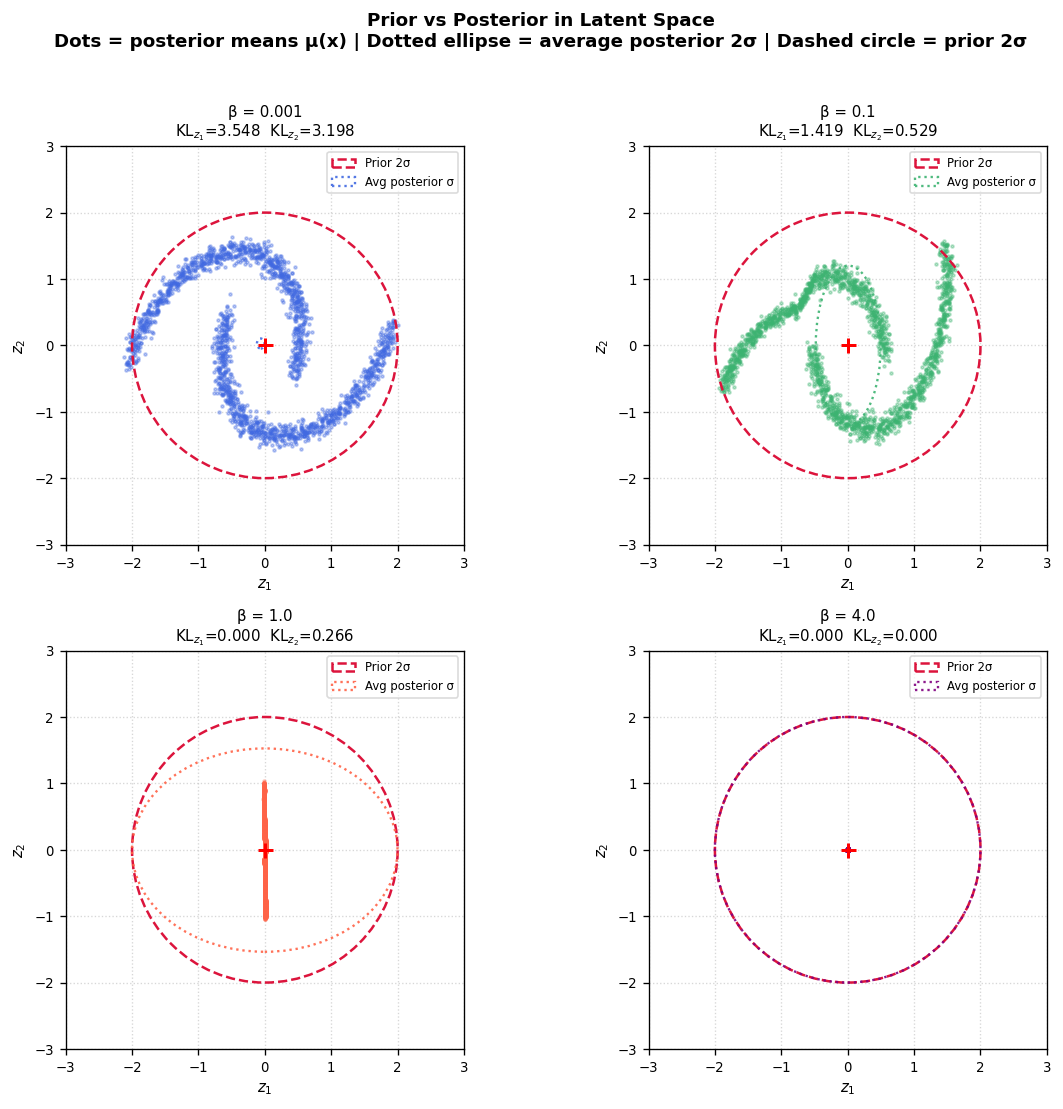


Reading the plot:
  β=0.001 → posterior ignores prior; clusters far from origin (high KL per dim).
  β=0.1   → mild regularisation; posterior partially pulled toward prior.
  β=1.0   → strong regularisation; posterior tightly clustered near prior.
  β=4.0  → all means collapse to origin; posterior indistinguishable from prior (KL≈0).



In [15]:
#Cell14
# Compute or store a value used by the following analysis.
# NOTE: exactly 4 colours — one per β value, matching the (1,4) subplot grid
colors_s1 = ['royalblue', 'mediumseagreen', 'tomato', 'purple']

# Redefine betas_s1 with exactly 4 values to match the 4 subplot columns

betas_s1 = [0.001, 0.1, 1.0, 4.0]

# ── Re-train / retrieve only the 4 needed models ─────────────────────────────
# Reuse already-trained models where beta matches; train fresh otherwise
print("Preparing 4 β-VAE models for Prior vs Posterior plot…")
for i, beta in enumerate(betas_s1):
    if beta in models_s1:
        # Model was already trained in the training cell — reuse it directly
        print(f"  β={beta:<6}  reused from models_s1")
    else:
        # Train a fresh model for this β value
        torch.manual_seed(seed + 200 + i)
        vae_tmp = BetaVAE(x_dim=2, h_dim=hidden_dim, z_dim=latent_dim, beta=beta)
        train_vae(vae_tmp, X, epochs=epochs_s1, lr=learning_rate)
        # Run forward pass to collect posterior parameters
        with torch.no_grad():
            _, mu_t, lv_t, _ = vae_tmp(X)
        # Store as numpy arrays: mu shape (2000,2), lv shape (2000,2)
        models_s1[beta] = (mu_t.numpy(), lv_t.numpy())
        print(f"  β={beta:<6}  trained and stored")
print("All 4 models ready.")

# Create a Matplotlib figure with 1 row and exactly 4 columns — one per β value
# figsize=(18, 4.5): wide and short is appropriate for a single-row layout
# Create a Matplotlib figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten() # Flatten 2D axes array into 1D list of 4 axes
# Add a title that explains what the plot shows.
fig.suptitle(
    # Execute this step as part of the connected β-VAE evaluation workflow.
    'Prior vs Posterior in Latent Space\n'
    # Compute or store a value used by the following analysis.
    'Dots = posterior means μ(x) | Dotted ellipse = average posterior 2σ | Dashed circle = prior 2σ',
    # Compute or store a value used by the following analysis.
    fontsize=11, fontweight='bold', y=1.02
# Close the current multi-line expression.
)

# Start a loop over models, β values, axes, and colours simultaneously
# axes is a flat 1D array of shape (4,) when nrows=1 → safe to zip directly
for ax, beta, color in zip(axes, betas_s1, colors_s1):

    # Retrieve pre-computed posterior means (mu) and log-variances (lv)
    # mu shape: (2000, 2)  — one mean vector per data point
    # lv shape: (2000, 2)  — one log-variance vector per data point
    mu, lv = models_s1[beta]

    # Apply the exponential function to recover standard deviation from log-variance.
    # std_mean shape: (2,) — average posterior std across the dataset, per latent dim
    std_mean = np.exp(0.5 * lv).mean(axis=0)   # average posterior std per dim

    # ── Posterior means scatter ───────────────────────────────────────────────
    # Draw a scatter plot of posterior means μ(x) in the 2D latent space
    # s=3: small dots so 2000 points don't overlap; zorder=2 puts dots behind ellipses
    ax.scatter(mu[:, 0], mu[:, 1], s=3, c=color, alpha=0.35,
               rasterized=True, zorder=2)

    # ── Prior 2σ ellipse ──────────────────────────────────────────────────────
    # The prior is N(0, I): mean=0, σ=1 in every direction → circle of radius 2
    # Ellipse takes DIAMETER not radius → width=4 means radius=2=2σ
    # Compute or store a value used by the following analysis.
    prior_ell = Ellipse(
        # Centre at origin because prior mean = 0
        xy=(0, 0), width=4, height=4,
        # Compute or store a value used by the following analysis.
        edgecolor='crimson', fc='none', lw=1.5, ls='--',
        zorder=3, label='Prior 2σ'
    # Close the current multi-line expression.
    )
    # Execute this step as part of the connected β-VAE evaluation workflow.
    ax.add_patch(prior_ell)

    # Draw a red cross at the prior mean (origin) for reference
    ax.plot(0, 0, 'r+', ms=9, mew=1.8, zorder=4)

    # ── Average posterior σ ellipse ───────────────────────────────────────────
    # Shows how wide the average posterior is relative to the prior circle
    # Centre = mean of all posterior means; width/height scaled by average σ per dim
    # Compute or store a value used by the following analysis.
    post_ell = Ellipse(
        # Centre at the mean of all posterior means across the dataset
        xy=(mu[:, 0].mean(), mu[:, 1].mean()),
        # width = 4 × std_mean[0]: the 4 keeps the same 2σ scaling as the prior ellipse
        width=4 * std_mean[0], height=4 * std_mean[1],
        # Compute or store a value used by the following analysis.
        edgecolor=color, fc='none', lw=1.4, ls=':', alpha=0.9,
        # Compute or store a value used by the following analysis.
        zorder=3, label='Avg posterior σ'
    # Close the current multi-line expression.
    )
    # Execute this step as part of the connected β-VAE evaluation workflow.
    ax.add_patch(post_ell)

    # ── KL annotation ─────────────────────────────────────────────────────────
    # Compute per-dimension KL: KL_d = -0.5*(1 + log σ²_d - μ²_d - σ²_d)
    # Averaged over all 2000 data points; shape: (2,) — one value per latent dim
    # Compute an average value used as a metric or plot annotation.
    kl_per_dim = -0.5 * np.mean(1 + lv - mu**2 - np.exp(lv), axis=0)

    # Add a title that explains what the plot shows.
    # Use LaTeX subscripts for clean rendering of z₁ and z₂
    ax.set_title(
        # Compute or store a value used by the following analysis.
        f'β = {beta}\n'
        # Compute or store a value used by the following analysis.
        f'KL$_{{z_1}}$={kl_per_dim[0]:.3f}  KL$_{{z_2}}$={kl_per_dim[1]:.3f}',
        fontsize=9
    # Close the current multi-line expression.
    )

    # Label the axes using LaTeX for proper subscript rendering
    ax.set_xlabel('$z_1$', fontsize=9)
    ax.set_ylabel('$z_2$', fontsize=9)

    # Force equal aspect ratio so the circular prior appears as a circle, not ellipse
    # Execute this step as part of the connected β-VAE evaluation workflow.
    ax.set_aspect('equal')

    # Auto-scale axis limits: at least ±3 (to always show full prior circle),
    # or 1.15× the furthest posterior mean if it extends beyond radius 3
    # Compute or store a value used by the following analysis.
    lim = max(3.0, np.abs(mu).max() * 1.15)
    # Execute this step as part of the connected β-VAE evaluation workflow.
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Keep tick label font size consistent with the small subplot size
    ax.tick_params(labelsize=8)

    # Add a legend so plotted elements can be identified.
    # framealpha=0.7: slight transparency so legend box doesn't hide data points
    ax.legend(fontsize=7, loc='upper right', framealpha=0.7)

# Adjust spacing so labels and titles do not overlap.
plt.tight_layout()

# Save the generated figure as an image file.
# dpi=150 produces a sharper output file than the default dpi=100
plt.savefig('plot_S1_prior_vs_posterior.png', bbox_inches='tight', dpi=150)

# Display the current Matplotlib figure in the notebook.
plt.show()

# Print progress or interpretation so the notebook output is easier to follow.
print("""
Reading the plot:
  β=0.001 → posterior ignores prior; clusters far from origin (high KL per dim).
  β=0.1   → mild regularisation; posterior partially pulled toward prior.
  β=1.0   → strong regularisation; posterior tightly clustered near prior.
  β=4.0  → all means collapse to origin; posterior indistinguishable from prior (KL≈0).
""")

---
## Section 2 — Reconstruction vs Original (10 β values)

β ∈ {0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 4, 8, 16}.

Each panel: grey = original data, colour = reconstruction x̂.  
MSE is annotated in each title.

In [16]:
#Cell15
#This Cell come From to reuse the trained model's data and avoiding retraining. 
# Time of emering this cell is (2:00 09.06.2026)
betas_s2  = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 4.0]
epochs_s2 = 6000

models_s2 = {}   # beta -> trained model
losses_s2 = {}   # beta -> training losses
recons_s2 = {}   # beta -> reconstruction numpy array

print("Preparing 8 β-VAE models for Reconstruction plot…")

for i, beta in enumerate(betas_s2):

    if beta == beta_low:
        models_s2[beta] = vae_low_beta
        losses_s2[beta] = losses_low
        recons_s2[beta] = recon_low_np
        status = "reused"

    elif beta == beta_std:
        models_s2[beta] = vae_std_beta
        losses_s2[beta] = losses_std
        recons_s2[beta] = recon_std_np
        status = "reused"

    elif beta == beta_high:
        models_s2[beta] = vae_high_beta
        losses_s2[beta] = losses_high
        recons_s2[beta] = recon_high_np
        status = "reused"

    else:
        torch.manual_seed(seed + 300 + i)

        vae_tmp = BetaVAE(
            x_dim=2,
            h_dim=hidden_dim,
            z_dim=latent_dim,
            beta=beta
        )

        loss_tmp = train_vae(
            vae_tmp,
            X,
            epochs=epochs_s2,
            lr=learning_rate
        )

        vae_tmp.eval()
        with torch.no_grad():
            recon_t, _, _, _ = vae_tmp(X)

        models_s2[beta] = vae_tmp
        losses_s2[beta] = loss_tmp
        recons_s2[beta] = recon_t.numpy()
        status = "trained"

    mse = np.mean((data - recons_s2[beta]) ** 2)

    print(f"  β={beta:<6}  MSE={mse:.5f}  {status}")

print("All 8 β-VAE models ready.")

Preparing 8 β-VAE models for Reconstruction plot…
  β=0.001   MSE=0.00053  reused
  β=0.01    MSE=0.00519  trained
  β=0.05    MSE=0.02371  trained
  β=0.1     MSE=0.04015  trained
  β=0.5     MSE=0.19598  trained
  β=1.0     MSE=0.32378  reused
  β=2.0     MSE=0.49984  trained
  β=4.0     MSE=0.50001  reused
All 8 β-VAE models ready.


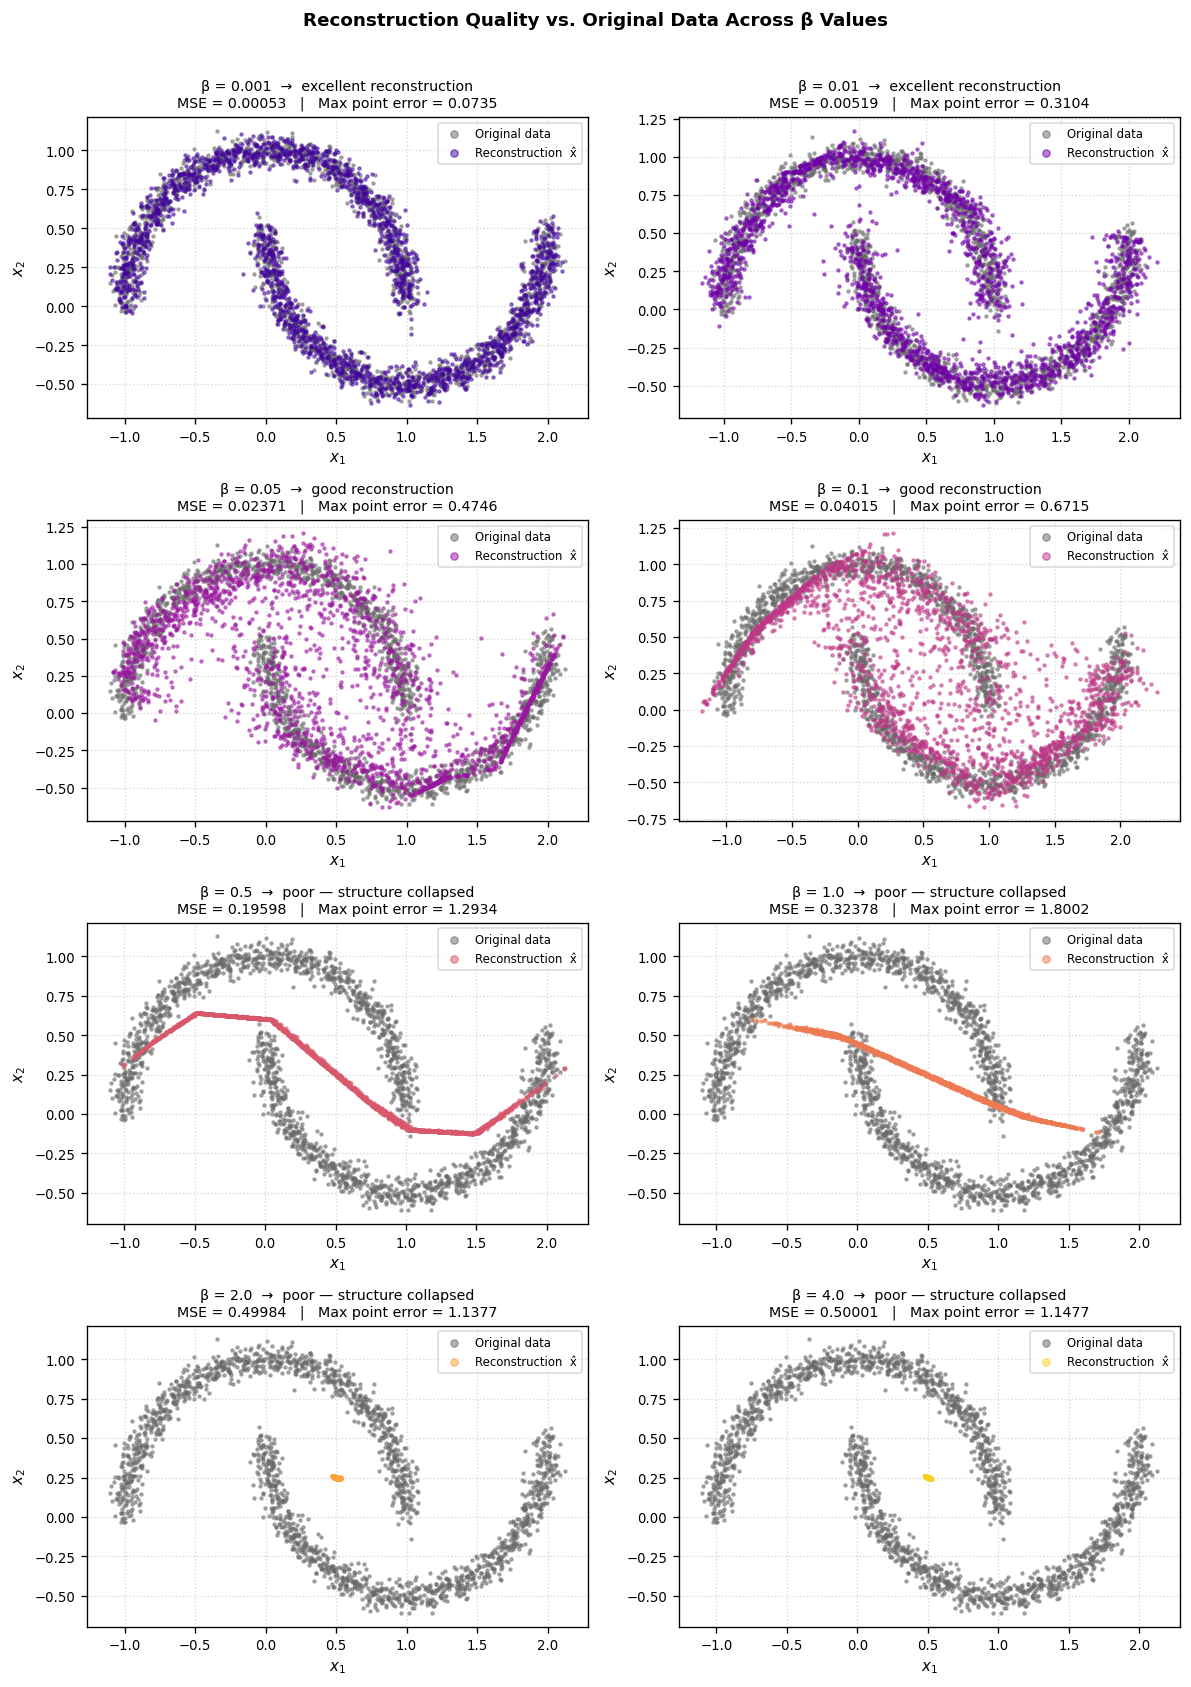


Reading the plot:
  Low  β (≈0.001) → reconstruction almost perfectly overlaps the original moon shape;
                     the encoder is free to use the latent space without regularisation.
  Mid  β (≈1.0)   → slight blurring visible; encoder starts trading detail for regularity.
  High β (≈4–16)  → reconstructions collapse toward the mean of the data distribution;
                     the two-moon structure is largely lost as the KL term dominates.
  Max point error  → the furthest individual point from its reconstruction; a large value
                     indicates the model is failing on the extremities of the data shape.



In [17]:
#Cell16
cmap_s2 = plt.cm.plasma(np.linspace(0.1, 0.9, len(betas_s2)))

# Create a 4×2 grid of subplots — one panel per β value (8 panels for 8 β values)
# figsize=(8,16): portrait layout suits a 4-row grid
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

# Flatten the (4,2) 2D array into a 1D list of 8 axes so zip works correctly
axes = axes.flatten()

# ── Figure-level title ────────────────────────────────────────────────────────
fig.suptitle(
    'Reconstruction Quality vs. Original Data Across β Values\n'
    ,
    fontsize=11, fontweight='bold', y=1.0, linespacing=1.0
)

# Loop over each subplot, β value, and plasma colour simultaneously
for ax, beta, color in zip(axes, betas_s2, cmap_s2):

    # Retrieve the reconstruction array for this β value, shape (2000, 2)
    recon = recons_s2[beta]

    # Compute mean squared error between original and reconstructed points
    mse = np.mean((data - recon) ** 2)

    # Compute per-point reconstruction error for annotation
    per_point_err = np.sqrt(np.mean((data - recon) ** 2, axis=1))
    max_err = per_point_err.max()

    # ── Original data (grey background layer) ─────────────────────────────────
    ax.scatter(data[:, 0], data[:, 1], s=3, c='dimgray', alpha=0.5,
           zorder=1, rasterized=True, label='Original data')

    # ── Reconstructed data (coloured foreground layer) ────────────────────────
    ax.scatter(recon[:, 0], recon[:, 1], s=3, color=color, alpha=0.5,
               zorder=2, rasterized=True, label='Reconstruction  x̂')

    # ── Per-panel title: β value + quality metrics ────────────────────────────
    # Qualitative label helps reader interpret the number at a glance
    if mse < 0.01:
        quality = 'excellent reconstruction'
    elif mse < 0.05:
        quality = 'good reconstruction'
    elif mse < 0.15:
        quality = 'moderate — structure partially lost'
    else:
        quality = 'poor — structure collapsed'

    ax.set_title(
        f'β = {beta}  →  {quality}\n'
        f'MSE = {mse:.5f}   |   Max point error = {max_err:.4f}',
        fontsize=8.5, pad=6
    )

    # Label axes with LaTeX subscripts for clean rendering
    ax.set_xlabel('$x_1$', fontsize=9)
    ax.set_ylabel('$x_2$', fontsize=9)
    ax.tick_params(labelsize=8)

    # Legend with slightly larger markers so the tiny dots are visible
    ax.legend(fontsize=7, loc='upper right', markerscale=2.5, framealpha=0.7)

# Adjust spacing so panel titles and axis labels do not overlap
plt.tight_layout()

# Save with high resolution for thesis / report use
plt.savefig('plot_S2_reconstruction_vs_original.png', bbox_inches='tight', dpi=150)
plt.show()

print("""
Reading the plot:
  Low  β (≈0.001) → reconstruction almost perfectly overlaps the original moon shape;
                     the encoder is free to use the latent space without regularisation.
  Mid  β (≈1.0)   → slight blurring visible; encoder starts trading detail for regularity.
  High β (≈4–16)  → reconstructions collapse toward the mean of the data distribution;
                     the two-moon structure is largely lost as the KL term dominates.
  Max point error  → the furthest individual point from its reconstruction; a large value
                     indicates the model is failing on the extremities of the data shape.
""")

---
## Section 3 — Posterior Collapse Illustration (3 β values)

Four complementary views for β ∈ {0.001, 1.0, 4.0}:

- **Row A** Per-dimension KL bar chart
- **Row B** Var\[μ_d(x)\] — how much the encoder output varies with input
- **Row C** Posterior mean scatter coloured by x₁ value — if colour separates along an axis, that dim is active
- **Row D** Mean posterior σ per dimension — collapsed dim → σ ≈ 1 (= prior)

---
## Section 4 — Evaluation: Reconstruction Error, KLD and ELBO vs β (10 β values)

β ∈ {0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 4, 8, 16}.

We also include a formatted **summary table** of final-epoch metrics for all models.

In [19]:
#Cell 17
##This cell emerged to avoid retraining

# Reuse the already trained models/losses/reconstructions from Cell 19.
# No model is trained again here.

betas_s4 = betas_s2
metrics_s4 = {}

print("Collecting metrics from already trained β-VAE models…")

for beta in betas_s4:

    recon_v = np.mean((data - recons_s2[beta]) ** 2)
    kld_v   = losses_s2[beta][-1][2]

    elbo_v = -(recon_v + kld_v)

    metrics_s4[beta] = {
        "recon": recon_v,
        "kld": kld_v,
        "elbo": elbo_v
    }

    print(
        f"  β={beta:<6}  "
        f"recon={recon_v:.5f}  "
        f"kld={kld_v:.5f}  "
        f"elbo={elbo_v:.5f}"
    )

print("Done.")

  β=0.001   recon=0.00053  kld=3.37274  elbo=-3.37327
  β=0.01    recon=0.00519  kld=2.04497  elbo=-2.05016
  β=0.05    recon=0.02371  kld=1.29139  elbo=-1.31510
  β=0.1     recon=0.04015  kld=0.97508  elbo=-1.01523
  β=0.5     recon=0.19598  kld=0.32122  elbo=-0.51719
  β=1.0     recon=0.32378  kld=0.13387  elbo=-0.45765
  β=2.0     recon=0.49984  kld=0.00002  elbo=-0.49986
  β=4.0     recon=0.50001  kld=0.00000  elbo=-0.50001
Done.


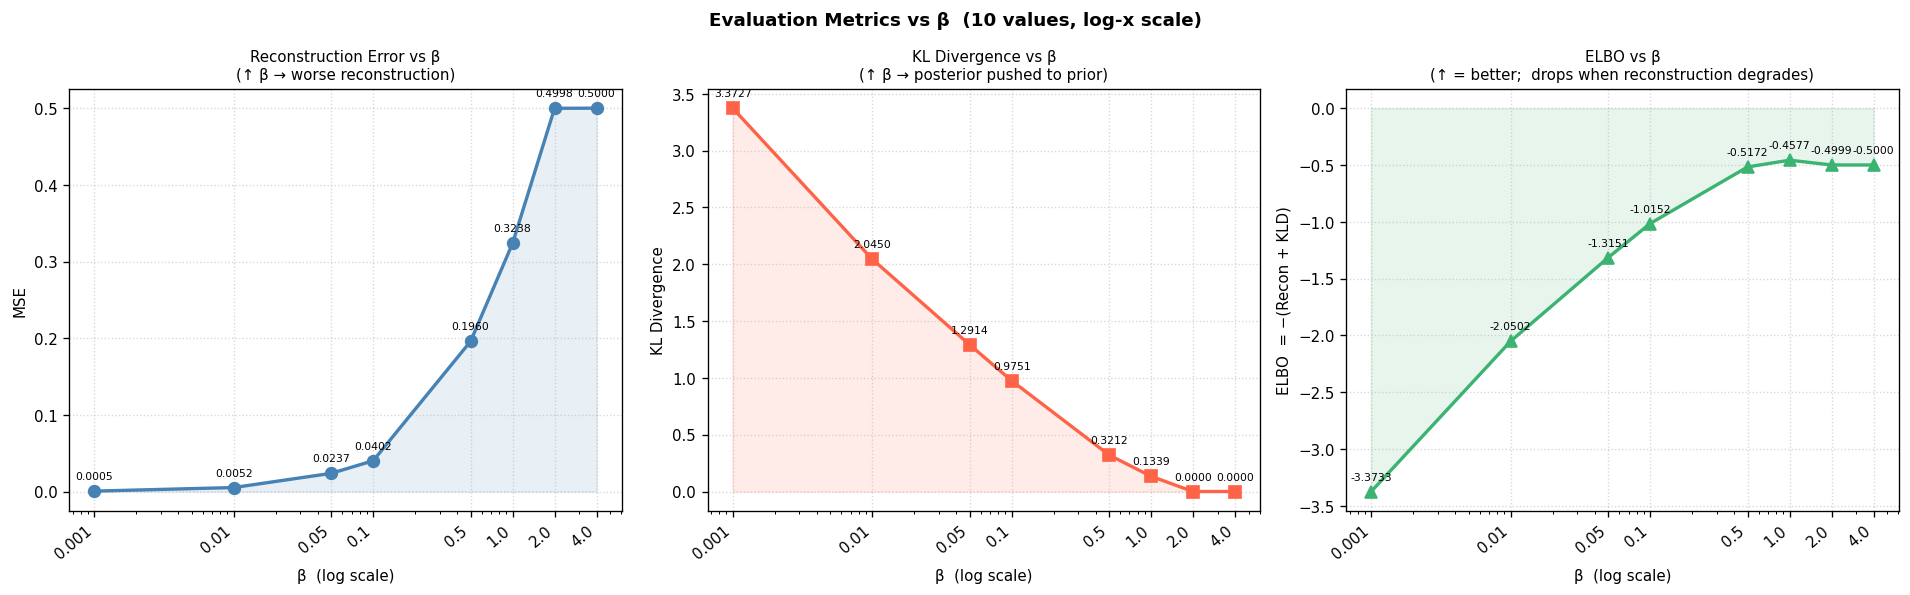

       β │    Recon MSE │        KLD │       ELBO
──────────────────────────────────────────────────
   0.001 │      0.00053 │    3.37274 │   -3.37327
    0.01 │      0.00519 │    2.04497 │   -2.05016
    0.05 │      0.02371 │    1.29139 │   -1.31510
     0.1 │      0.04015 │    0.97508 │   -1.01523
     0.5 │      0.19598 │    0.32122 │   -0.51719
     1.0 │      0.32378 │    0.13387 │   -0.45765
     2.0 │      0.49984 │    0.00002 │   -0.49986
     4.0 │      0.50001 │    0.00000 │   -0.50001


In [20]:
#Cells18
recon_vals = [metrics_s4[b]['recon'] for b in betas_s4]
kld_vals   = [metrics_s4[b]['kld']   for b in betas_s4]
elbo_vals  = [metrics_s4[b]['elbo']  for b in betas_s4]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Evaluation Metrics vs β  (10 values, log-x scale)',
    fontsize=11, fontweight='bold'
)

# ── Reconstruction Error ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(betas_s4, recon_vals, 'o-', color='steelblue', lw=2, ms=7, zorder=3)
ax.fill_between(betas_s4, recon_vals, alpha=0.12, color='steelblue')
for x, y in zip(betas_s4, recon_vals):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 7), ha='center', fontsize=6.5)
ax.set_xscale('log')
ax.set_xlabel('β  (log scale)')
ax.set_ylabel('MSE')
ax.set_title('Reconstruction Error vs β\n(↑ β → worse reconstruction)')
ax.set_xticks(betas_s4)
ax.set_xticklabels([str(b) for b in betas_s4], rotation=40, ha='right')

# ── KL Divergence ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(betas_s4, kld_vals, 's-', color='tomato', lw=2, ms=7, zorder=3)
ax.fill_between(betas_s4, kld_vals, alpha=0.12, color='tomato')
for x, y in zip(betas_s4, kld_vals):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 7), ha='center', fontsize=6.5)
ax.set_xscale('log')
ax.set_xlabel('β  (log scale)')
ax.set_ylabel('KL Divergence')
ax.set_title('KL Divergence vs β\n(↑ β → posterior pushed to prior)')
ax.set_xticks(betas_s4)
ax.set_xticklabels([str(b) for b in betas_s4], rotation=40, ha='right')

# ── ELBO ──────────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(betas_s4, elbo_vals, '^-', color='mediumseagreen', lw=2, ms=7, zorder=3)
ax.fill_between(betas_s4, elbo_vals, alpha=0.12, color='mediumseagreen')
for x, y in zip(betas_s4, elbo_vals):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 7), ha='center', fontsize=6.5)
ax.set_xscale('log')
ax.set_xlabel('β  (log scale)')
ax.set_ylabel('ELBO  = −(Recon + KLD)')
ax.set_title('ELBO vs β\n(↑ = better;  drops when reconstruction degrades)')
ax.set_xticks(betas_s4)
ax.set_xticklabels([str(b) for b in betas_s4], rotation=40, ha='right')

plt.tight_layout()
plt.savefig('plot_S4_metrics_vs_beta.png', bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'β':>8} │ {'Recon MSE':>12} │ {'KLD':>10} │ {'ELBO':>10}")
print('─' * 50)
for b in betas_s4:
    m = metrics_s4[b]
    print(f"{b:>8} │ {m['recon']:>12.5f} │ {m['kld']:>10.5f} │ {m['elbo']:>10.5f}")

---
## Section 5 — Extended β Sweep: Collapse Analysis

β swept across **12 values** from 0.001 → 64.  
Four panels in a 2×2 grid:

- **(a)** Reconstruction Error vs β  
- **(b)** Total KLD vs β  
- **(c)** Per-dimension KL vs β — curve dipping below threshold = collapse  
- **(d)** Number of collapsed dimensions vs β
- **(e)** Unfortunately, the following cell is retraining the model

In [21]:
# ── β sweep — MUST run before the plotting cell ───────────────────────────────
# Reuses models_s2, losses_s2 from Cell 19 — no retraining.
# Defines: sweep_recon, sweep_kld, sweep_kld_dim, sweep_mu_var,
#          n_collapsed, collapsed, COLL_THRESH
# All of these are required by the plotting cell below.

betas_sweep = betas_s2
COLL_THRESH = 0.1

sweep_recon   = []
sweep_kld     = []
sweep_elbo    =[]
sweep_kld_dim = []
sweep_mu_var  = []


print(f"β sweep over {len(betas_sweep)} already-trained models...")

for beta in betas_sweep:

    # Retrieve already-trained model and its stored loss history
    vae_s = models_s2[beta]
    ls    = losses_s2[beta]
    

    # Eval mode — no gradient tracking needed
    vae_s.eval()
    with torch.no_grad():
        _, mu_s, lv_s, _ = vae_s(X)

    mu_s_np = mu_s.numpy()
    lv_s_np = lv_s.numpy()
    elbo_val = -(ls[-1][1] + ls[-1][2])
    # Final-epoch reconstruction MSE and KLD from stored training history
    sweep_recon.append(ls[-1][1])
    sweep_kld.append(ls[-1][2])
    sweep_elbo.append(elbo_val)

    # Per-dimension KL divergence — shape (2,)
    sweep_kld_dim.append(per_dim_kl(mu_s_np, lv_s_np))

    # Variance of posterior means per dim — shape (2,)
    sweep_mu_var.append(mu_s_np.var(axis=0))

    print(
        f"  β={beta:<6}  "
        f"recon={ls[-1][1]:.5f}  "
        f"kld={ls[-1][2]:.5f}  "
        f"elbo={elbo_val:.5f} "
        f"kld_dims={np.round(sweep_kld_dim[-1], 4)}"
    )

# Convert all lists to numpy arrays for indexing and plotting
sweep_recon   = np.array(sweep_recon)
sweep_kld     = np.array(sweep_kld)
sweep_elbo    = np.array(sweep_elbo)
sweep_kld_dim = np.array(sweep_kld_dim)   # shape (8, 2)
sweep_mu_var  = np.array(sweep_mu_var)     # shape (8, 2)

# Collapse detection: dimension d is collapsed if KL_d < COLL_THRESH
collapsed   = (sweep_kld_dim < COLL_THRESH).astype(int)
n_collapsed = collapsed.sum(axis=1)        # shape (8,)

print(f"\nSweep complete — all plotting variables are now defined.")
print(f"  sweep_recon   shape: {sweep_recon.shape}")
print(f"  sweep_kld     shape: {sweep_kld.shape}")
print(f" sweep_elbo     shape: {sweep_elbo.shape}")
print(f"  sweep_kld_dim shape: {sweep_kld_dim.shape}")
print(f"  n_collapsed        : {n_collapsed}")

β sweep over 8 already-trained models...
  β=0.001   recon=0.00051  kld=3.37274  elbo=-3.37324 kld_dims=[3.5479 3.1977]
  β=0.01    recon=0.00514  kld=2.04497  elbo=-2.05011 kld_dims=[2.4449 1.6469]
  β=0.05    recon=0.02451  kld=1.29139  elbo=-1.31590 kld_dims=[0.9251 1.6568]
  β=0.1     recon=0.04290  kld=0.97508  elbo=-1.01799 kld_dims=[0.5071 1.4459]
  β=0.5     recon=0.18900  kld=0.32122  elbo=-0.51021 kld_dims=[0.     0.6427]
  β=1.0     recon=0.31629  kld=0.13387  elbo=-0.45017 kld_dims=[0.     0.2664]
  β=2.0     recon=0.49996  kld=0.00002  elbo=-0.49998 kld_dims=[0. 0.]
  β=4.0     recon=0.49988  kld=0.00000  elbo=-0.49988 kld_dims=[0. 0.]

Sweep complete — all plotting variables are now defined.
  sweep_recon   shape: (8,)
  sweep_kld     shape: (8,)
 sweep_elbo     shape: (8,)
  sweep_kld_dim shape: (8, 2)
  n_collapsed        : [0 0 0 0 1 1 2 2]


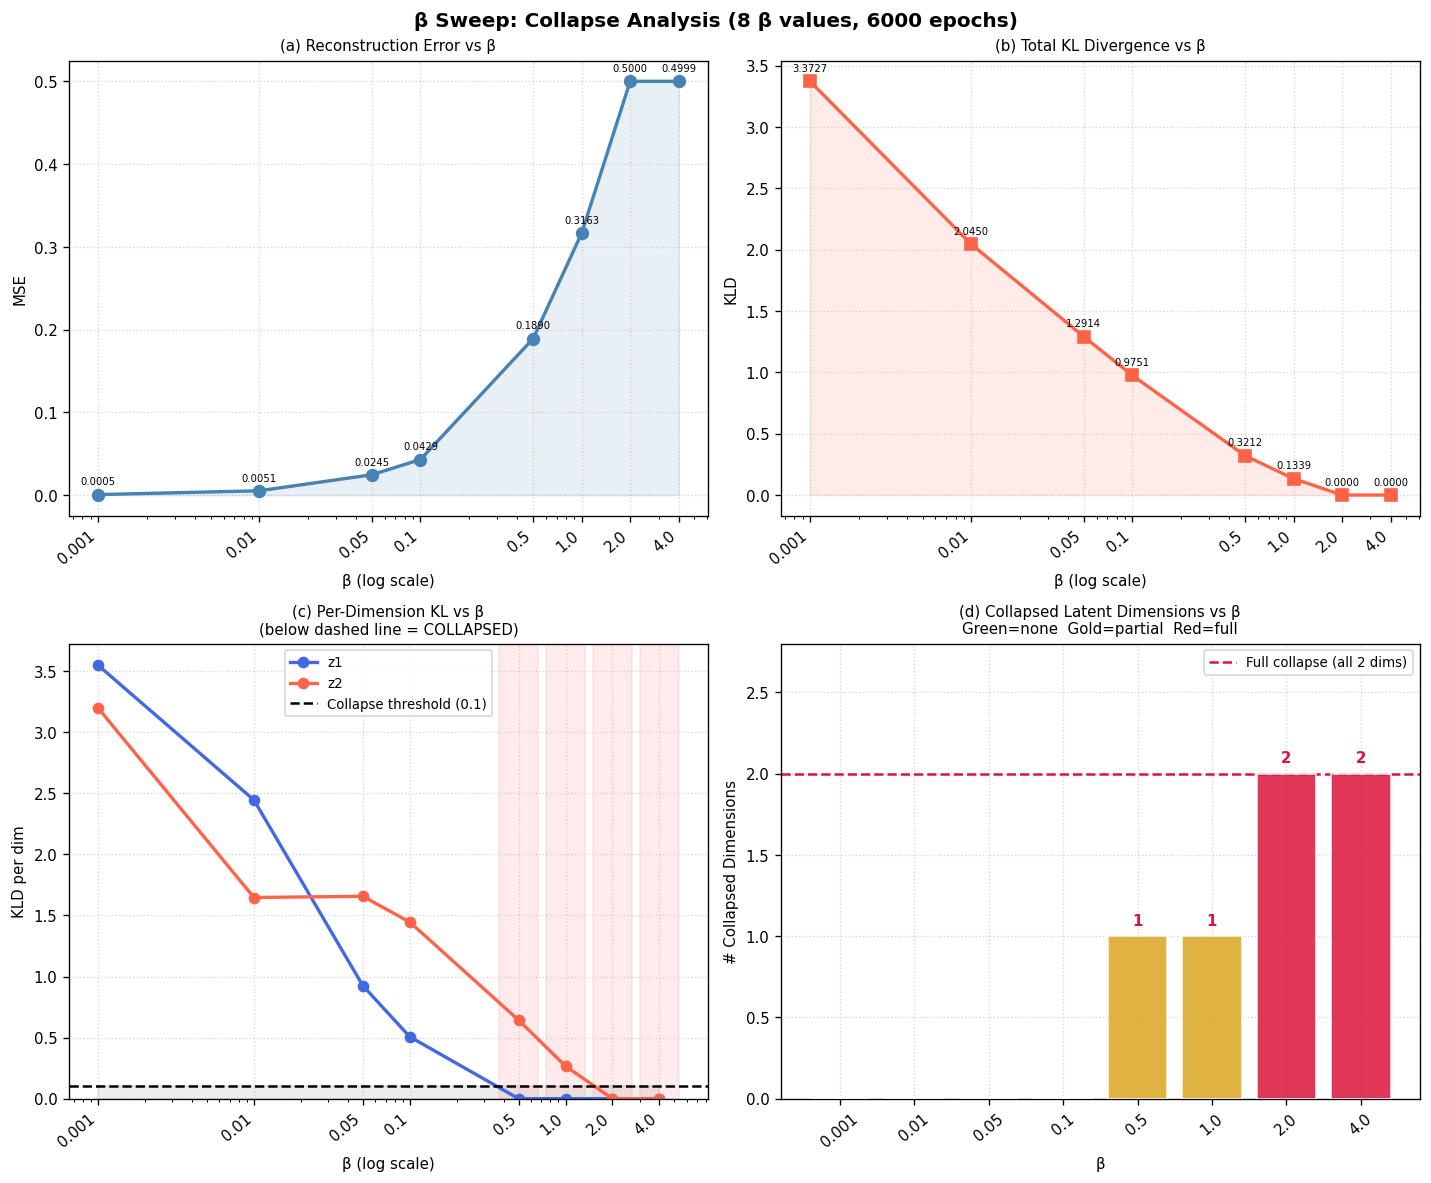

       β │    Recon MSE │        KLD │       ELBO │  Collapsed
──────────────────────────────────────────────────────────────
   0.001 │      0.00051 │    3.37274 │   -3.37327 │       none
    0.01 │      0.00514 │    2.04497 │   -2.05016 │       none
    0.05 │      0.02451 │    1.29139 │   -1.31510 │       none
     0.1 │      0.04290 │    0.97508 │   -1.01523 │       none
     0.5 │      0.18900 │    0.32122 │   -0.51719 │    partial
     1.0 │      0.31629 │    0.13387 │   -0.45765 │    partial
     2.0 │      0.49996 │    0.00002 │   -0.49986 │       FULL
     4.0 │      0.49988 │    0.00000 │   -0.50001 │       FULL

Collapse summary:
  Threshold = 0.1 nats per dimension.
  First β with ≥1 collapsed dim : 0.5
  First β with full collapse     : 2.0



In [22]:
betas_sweep = betas_s2
beta_labels = [str(b) for b in betas_sweep]
dim_colors  = ['royalblue', 'tomato', 'mediumseagreen', 'purple']


sweep_elbo = np.array([metrics_s4[b]['elbo'] for b in betas_sweep])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))




fig.suptitle(
    f'β Sweep: Collapse Analysis '
    f'({len(betas_s2)} β values, {epochs_s2} epochs)',
    fontsize=12,
    fontweight='bold'
)

# ── (a) Reconstruction Error ──────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(betas_sweep, sweep_recon, 'o-', color='steelblue', lw=2, ms=7)
ax.fill_between(betas_sweep, sweep_recon, alpha=0.12, color='steelblue')
ax.set_xscale('log'); ax.set_xlabel('β (log scale)'); ax.set_ylabel('MSE')
ax.set_title('(a) Reconstruction Error vs β')
ax.set_xticks(betas_sweep)
ax.set_xticklabels(beta_labels, rotation=40, ha='right')
for x, y in zip(betas_sweep, sweep_recon):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 6), ha='center', fontsize=6)

# ── (b) Total KLD ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(betas_sweep, sweep_kld, 's-', color='tomato', lw=2, ms=7)
ax.fill_between(betas_sweep, sweep_kld, alpha=0.12, color='tomato')
ax.set_xscale('log'); ax.set_xlabel('β (log scale)'); ax.set_ylabel('KLD')
ax.set_title('(b) Total KL Divergence vs β')
ax.set_xticks(betas_sweep)
ax.set_xticklabels(beta_labels, rotation=40, ha='right')
for x, y in zip(betas_sweep, sweep_kld):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                xytext=(0, 6), ha='center', fontsize=6)

# ── (c) Per-dim KL ────────────────────────────────────────────────────────────
ax = axes[1, 0]
for d in range(latent_dim):
    ax.plot(betas_sweep, sweep_kld_dim[:, d],
            'o-', color=dim_colors[d], lw=2, ms=6, label=f'z{d+1}')
ax.axhline(COLL_THRESH, color='black', ls='--', lw=1.5,
           label=f'Collapse threshold ({COLL_THRESH})')
ax.fill_between(betas_sweep, 0, COLL_THRESH, alpha=0.07, color='black')
# shade region below threshold red when any dim collapses
for i, beta in enumerate(betas_sweep):
    if n_collapsed[i] > 0:
        ax.axvspan(beta * 0.75, beta * 1.33, alpha=0.08, color='red')
ax.set_xscale('log'); ax.set_xlabel('β (log scale)'); ax.set_ylabel('KLD per dim')
ax.set_title('(c) Per-Dimension KL vs β\n(below dashed line = COLLAPSED)')
ax.set_xticks(betas_sweep)
ax.set_xticklabels(beta_labels, rotation=40, ha='right')
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)

# ── (d) Number of collapsed dims ──────────────────────────────────────────────
ax = axes[1, 1]
bar_colors = ['mediumseagreen' if nc == 0 else
              'goldenrod'      if nc < latent_dim else
              'crimson'
              for nc in n_collapsed]
bars = ax.bar(beta_labels, n_collapsed, color=bar_colors,
              alpha=0.85, edgecolor='white', zorder=3)
ax.axhline(latent_dim, color='crimson', ls='--', lw=1.5,
           label=f'Full collapse (all {latent_dim} dims)')
ax.set_xlabel('β'); ax.set_ylabel('# Collapsed Dimensions')
ax.set_title('(d) Collapsed Latent Dimensions vs β\nGreen=none  Gold=partial  Red=full')
ax.set_ylim(0, latent_dim + 0.8)
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=40)
for bar, nc in zip(bars, n_collapsed):
    if nc > 0:
        ax.text(bar.get_x() + bar.get_width()/2, nc + 0.05,
                str(nc), ha='center', va='bottom',
                fontweight='bold', fontsize=9, color='crimson')

plt.tight_layout()
plt.savefig('plot_S5_beta_sweep_collapse.png', bbox_inches='tight')
plt.show()
# ── Summary table — includes ELBO ─────────────────────────────────────────────
print(f"{'β':>8} │ {'Recon MSE':>12} │ {'KLD':>10} │ {'ELBO':>10} │ {'Collapsed':>10}")
print('─' * 62)
for b, recon, kld, elbo, nc in zip(
        betas_sweep, sweep_recon, sweep_kld, sweep_elbo, n_collapsed):
    status = 'none' if nc == 0 else ('partial' if nc < latent_dim else 'FULL')
    print(f"{b:>8} │ {recon:>12.5f} │ {kld:>10.5f} │ {elbo:>10.5f} │ {status:>10}")

print(f"""
Collapse summary:
  Threshold = {COLL_THRESH} nats per dimension.
  First β with ≥1 collapsed dim : {betas_sweep[np.argmax(n_collapsed > 0)]}
  First β with full collapse     : {betas_sweep[np.argmax(n_collapsed == latent_dim)] if (n_collapsed == latent_dim).any() else 'not reached'}
""")

---
## Section 6 — Training Loss Curves: Standard β-VAE vs Free-Bits β-VAE

3 rows × 3 columns:
- **Columns**: β ∈ {0.001, 1.0, 4.0}
- **Rows**: Total ELBO loss  |  Reconstruction MSE  |  KL Divergence

Solid = Standard β-VAE, Dashed = Free-Bits β-VAE.

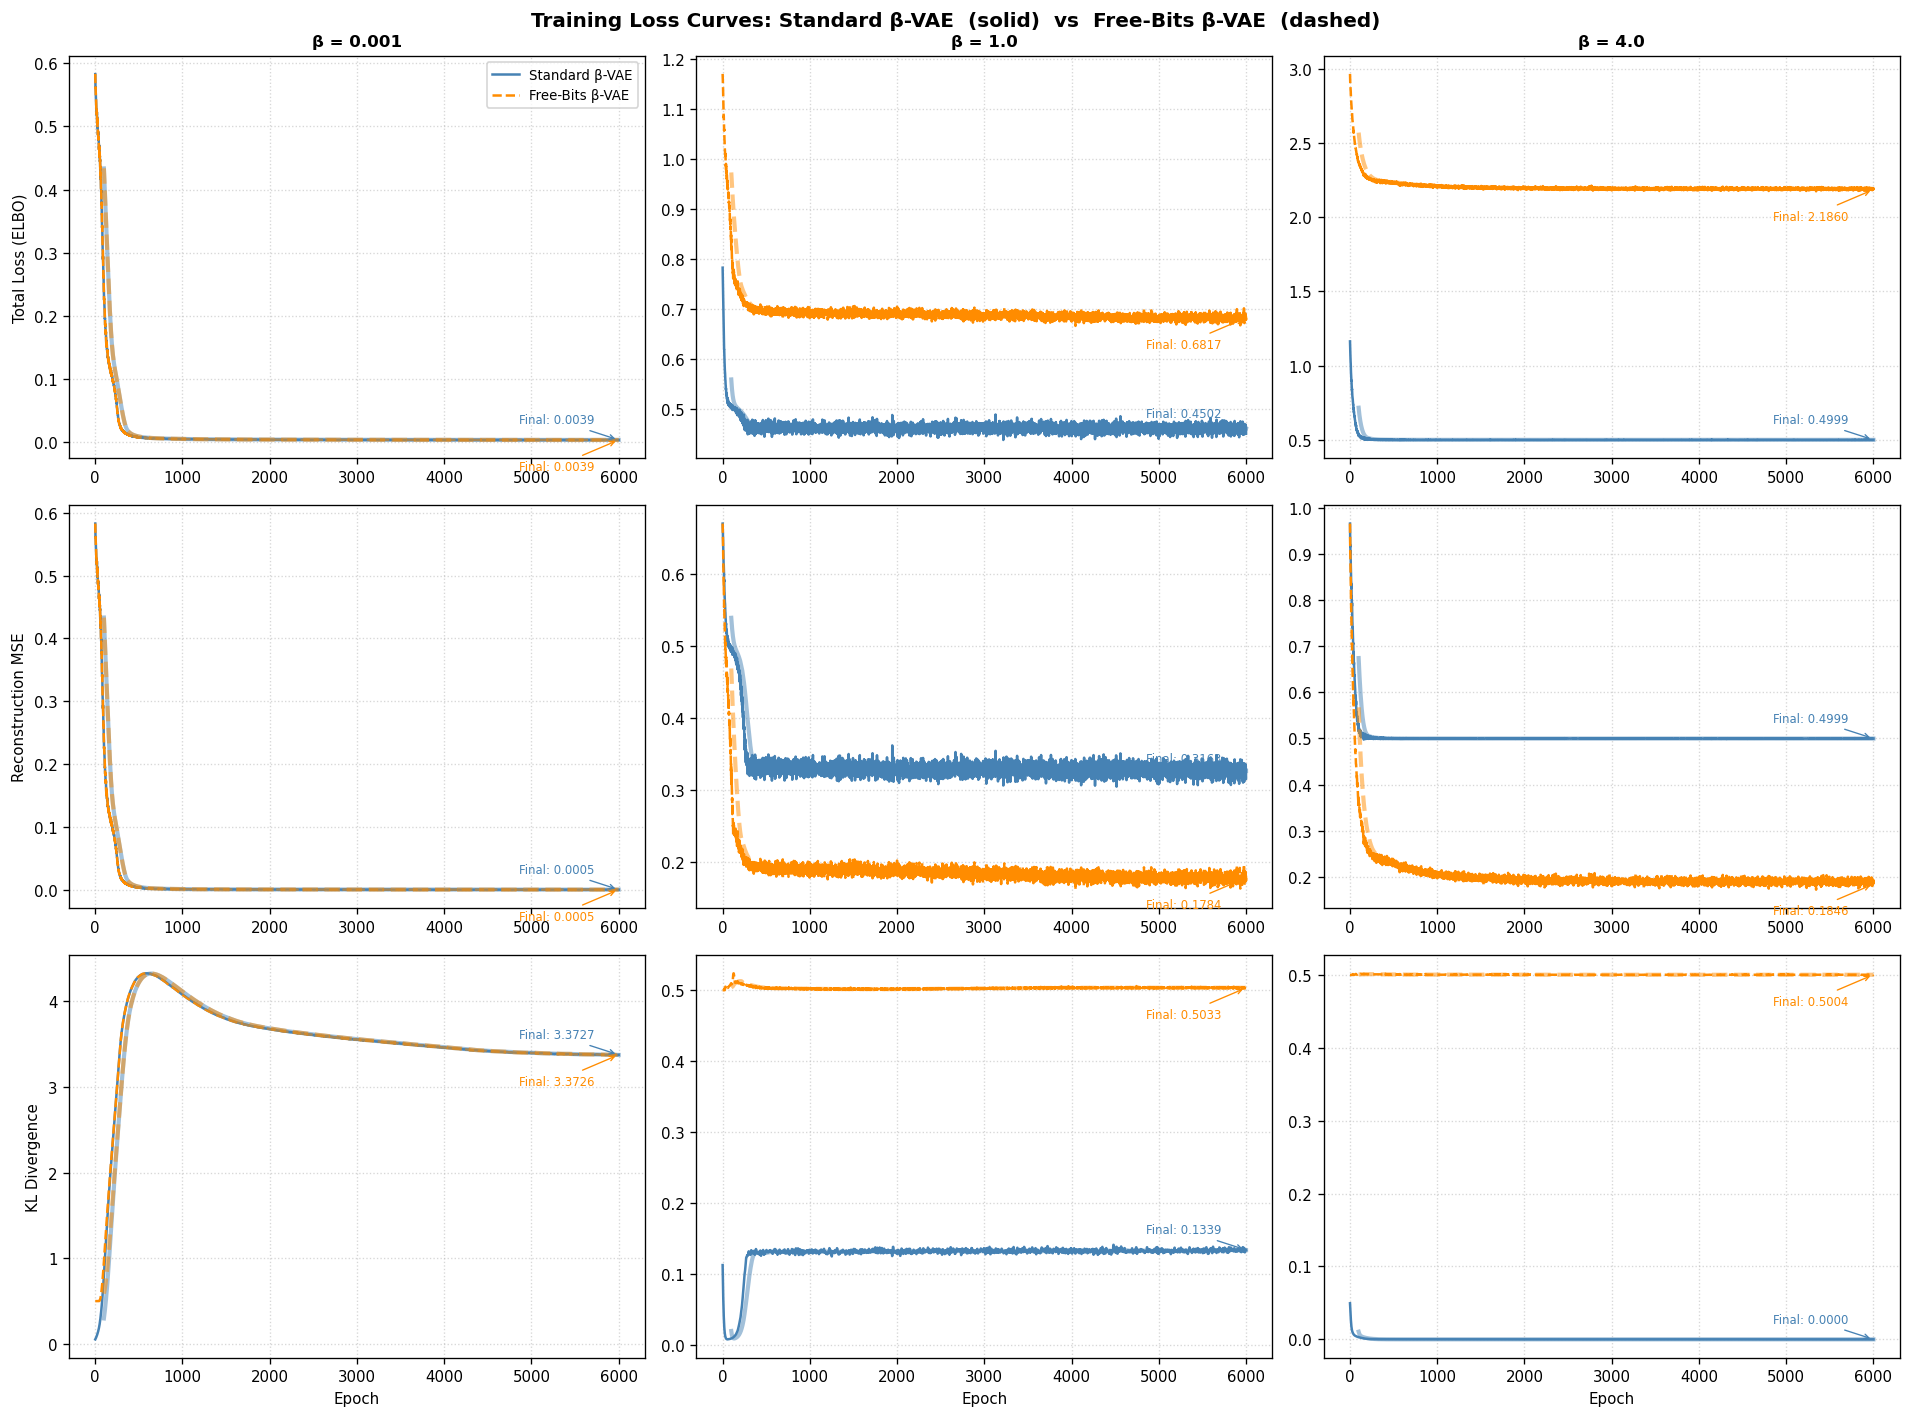


Reading the curves:
  Row 1 (Total Loss): lower = better. Free-Bits often converges to a slightly
         higher total loss because its clamped KLD is an inflated lower bound.
  Row 2 (Recon MSE): Free-Bits should match or beat standard β-VAE at high β,
         because it prevents the encoder from giving up on dimensions.
  Row 3 (KLD): Free-Bits KLD never drops below the free_bits floor (0.5 × z_dim),
         confirming the hinge prevents collapse.



In [23]:
loss_pairs = [
    (losses_low,  losses_low_opt,  f'β = {beta_low}'),
    (losses_std,  losses_std_opt,  f'β = {beta_std}'),
    (losses_high, losses_high_opt, f'β = {beta_high}'),
]

row_labels = ['Total Loss (ELBO)', 'Reconstruction MSE', 'KL Divergence']
row_idx    = [0, 1, 2]   # index into losses tuple
row_colors_std = ['#1f4e79', '#1f4e79', '#1f4e79']
row_colors_fb  = ['#c55a11', '#c55a11', '#c55a11']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle(
    'Training Loss Curves: Standard β-VAE  (solid)  vs  Free-Bits β-VAE  (dashed)',
    fontsize=12, fontweight='bold'
)

for col, (l_std, l_fb, col_title) in enumerate(loss_pairs):
    ep       = np.arange(1, len(l_std) + 1)
    arr_std  = np.array(l_std)   # (epochs, 3)
    arr_fb   = np.array(l_fb)

    for row, (ridx, rlabel) in enumerate(zip(row_idx, row_labels)):
        ax = axes[row, col]

        y_std = arr_std[:, ridx]
        y_fb  = arr_fb[:,  ridx]

        ax.plot(ep, y_std, lw=1.5, color='steelblue',  label='Standard β-VAE')
        ax.plot(ep, y_fb,  lw=1.5, color='darkorange',
                ls='--', label='Free-Bits β-VAE')

        # moving average for clarity
        window = max(1, len(ep) // 60)
        ax.plot(ep[window-1:],
                np.convolve(y_std, np.ones(window)/window, mode='valid'),
                lw=2.5, color='steelblue', alpha=0.5)
        ax.plot(ep[window-1:],
                np.convolve(y_fb,  np.ones(window)/window, mode='valid'),
                lw=2.5, color='darkorange', alpha=0.5, ls='--')

        # final value annotation
        ax.annotate(f'Final: {y_std[-1]:.4f}',
                    xy=(ep[-1], y_std[-1]),
                    xytext=(-60, 10), textcoords='offset points',
                    fontsize=7, color='steelblue',
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8))
        ax.annotate(f'Final: {y_fb[-1]:.4f}',
                    xy=(ep[-1], y_fb[-1]),
                    xytext=(-60, -18), textcoords='offset points',
                    fontsize=7, color='darkorange',
                    arrowprops=dict(arrowstyle='->', color='darkorange', lw=0.8))

        if row == 0:
            ax.set_title(col_title, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(rlabel)
        if row == 2:
            ax.set_xlabel('Epoch')
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_S6_training_curves.png', bbox_inches='tight')
plt.show()
print("""
Reading the curves:
  Row 1 (Total Loss): lower = better. Free-Bits often converges to a slightly
         higher total loss because its clamped KLD is an inflated lower bound.
  Row 2 (Recon MSE): Free-Bits should match or beat standard β-VAE at high β,
         because it prevents the encoder from giving up on dimensions.
  Row 3 (KLD): Free-Bits KLD never drops below the free_bits floor (0.5 × z_dim),
         confirming the hinge prevents collapse.
""")

In [24]:
# ── Free-Bits Reconstruction vs Original  (8 β values) ───────────────────────
# β values matching exactly what was requested: {0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 4}
# These are the same 8 values already used in betas_s2, so we train Free-Bits
# models for each and collect their reconstructions in a dedicated dict.
models_fb = {}
losses_fb = {}
betas_fb   = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 4.0]
epochs_fb  = 6000     # same training budget as Section 2 standard β-VAE
recons_fb  = {}       # beta -> recon_np  shape (2000, 2)
free_bits  = 0.5      # hinge threshold — same as BetaVAE_Bits default

print("Training 8 Free-Bits β-VAE models…")
for i, beta in enumerate(betas_fb):

    # Reuse already-trained Free-Bits models where beta matches Cell 9
    if beta == beta_low:
        # vae_low_beta_opt was trained in Cell 9 — forward pass only
        with torch.no_grad():
            recon_t, _, _, _ = vae_low_beta_opt(X)
        recons_fb[beta] = recon_t.numpy()
        print(f"  β={beta:<6}  reused from vae_low_beta_opt")

    elif beta == beta_std:
        # vae_std_beta_opt was trained in Cell 9 — forward pass only
        with torch.no_grad():
            recon_t, _, _, _ = vae_std_beta_opt(X)
        recons_fb[beta] = recon_t.numpy()
        print(f"  β={beta:<6}  reused from vae_std_beta_opt")

    elif beta == beta_high:
        # vae_high_beta_opt was trained in Cell 9 — forward pass only
        with torch.no_grad():
            recon_t, _, _, _ = vae_high_beta_opt(X)
        recons_fb[beta] = recon_t.numpy()
        print(f"  β={beta:<6}  reused from vae_high_beta_opt")

    else:
        # Train a fresh Free-Bits model for this β value
        # Seed offset 600+i keeps these runs reproducible and distinct from
        # all other training seeds used elsewhere in the notebook
        torch.manual_seed(seed + 600 + i)
        vae_fb_tmp = BetaVAE_Bits(
            x_dim=2, h_dim=hidden_dim, z_dim=latent_dim,
            beta=beta, free_bits=free_bits
        )
        train_vae(vae_fb_tmp, X, epochs=epochs_fb, lr=learning_rate)

        # Collect reconstruction: run full forward pass, no gradients needed
        with torch.no_grad():
            recon_t, _, _, _ = vae_fb_tmp(X)
        recons_fb[beta] = recon_t.numpy()   # shape (2000, 2)
        print(f"  β={beta:<6}  MSE={np.mean((data - recons_fb[beta])**2):.5f}  trained")

print("All 8 Free-Bits models ready.")

Training 8 Free-Bits β-VAE models…
  β=0.001   reused from vae_low_beta_opt
  β=0.01    MSE=0.00521  trained
  β=0.05    MSE=0.02299  trained
  β=0.1     MSE=0.03884  trained
  β=0.5     MSE=0.14440  trained
  β=1.0     reused from vae_std_beta_opt
  β=2.0     MSE=0.19952  trained
  β=4.0     reused from vae_high_beta_opt
All 8 Free-Bits models ready.


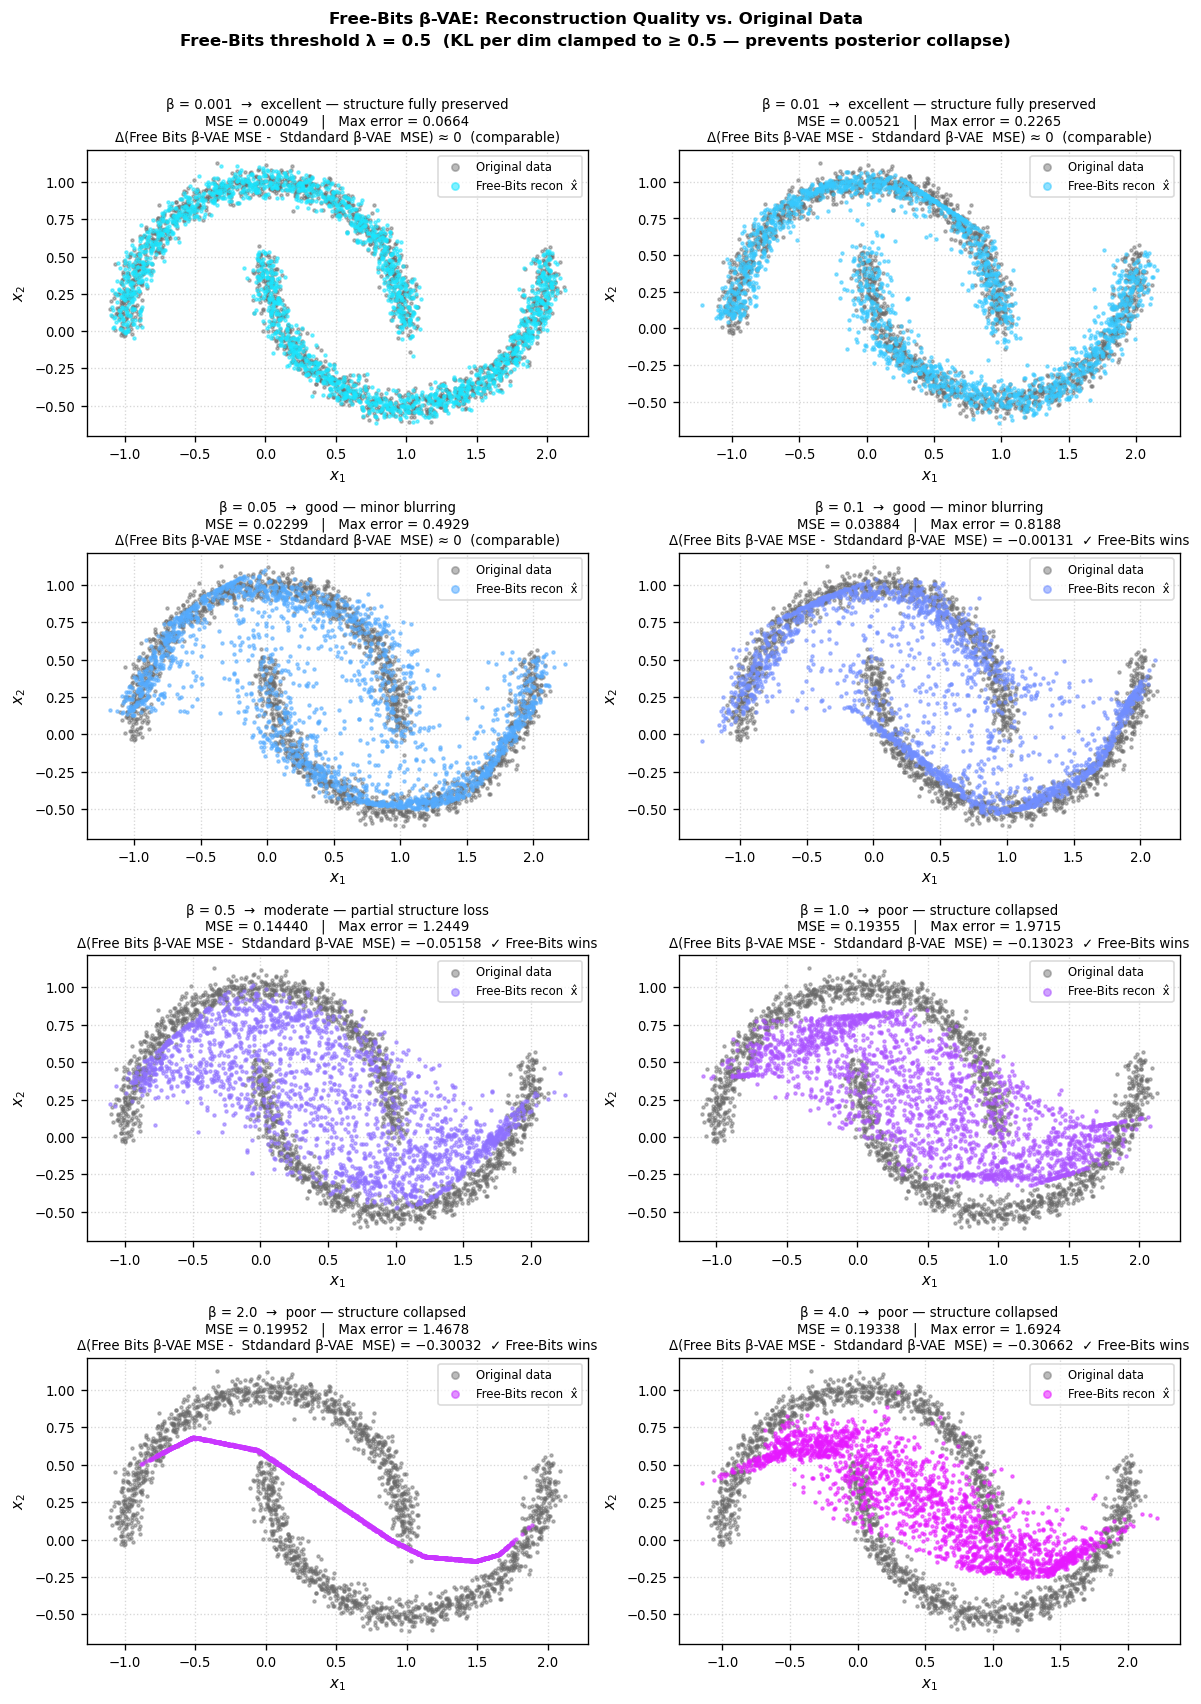


     β │  Free-Bits MSE │  Std β-VAE MSE │   Δ (std − fb)
──────────────────────────────────────────────────────────
 0.001 │        0.00049 │        0.00053 │       +0.00004  ≈ tie
  0.01 │        0.00521 │        0.00519 │       -0.00003  ≈ tie
  0.05 │        0.02299 │        0.02371 │       +0.00073  ≈ tie
   0.1 │        0.03884 │        0.04015 │       +0.00131  ← FB better
   0.5 │        0.14440 │        0.19598 │       +0.05158  ← FB better
   1.0 │        0.19355 │        0.32378 │       +0.13023  ← FB better
   2.0 │        0.19952 │        0.49984 │       +0.30032  ← FB better
   4.0 │        0.19338 │        0.50001 │       +0.30662  ← FB better

Reading the plot:
  Low  β (0.001–0.1) → Free-Bits and standard β-VAE behave similarly; the KL
                        floor has no effect when β is small (KL is naturally high).
  Mid  β (0.5–1.0)   → Free-Bits begins to outperform standard β-VAE; the hinge
                        prevents individual latent dims from collapsing 

'\n“Across larger β values, Free Bits consistently achieves lower reconstruction MSE than standard \nβ-VAE, indicating that it preserves latent information more effectively under stronger KL regularization”\n'

In [33]:
# ── Plot: Free-Bits Reconstruction vs Original  (4 rows × 2 cols) ────────────
# One panel per β value; grey = original Noisy Moons, colour = Free-Bits x̂
# Colormap: 'cool' contains no warm tones → always distinct from dimgray original

# cool colormap: blue-to-cyan range, clean contrast against the grey originals
cmap_fb = plt.cm.cool(np.linspace(0.1, 0.9, len(betas_fb)))

# 4 rows × 2 cols gives exactly 8 panels — one per β value; portrait layout
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

# Flatten (4,2) 2D array → 1D list of 8 axes so zip works correctly
axes = axes.flatten()

# ── Figure-level title ────────────────────────────────────────────────────────
fig.suptitle(
    'Free-Bits β-VAE: Reconstruction Quality vs. Original Data\n'
    f'Free-Bits threshold λ = {free_bits}  '
    f'(KL per dim clamped to ≥ {free_bits} — prevents posterior collapse)',
    fontsize=10, fontweight='bold', y=1.01, linespacing=1.6
)

# Loop over each subplot, β value, and colour simultaneously
for ax, beta, color in zip(axes, betas_fb, cmap_fb):

    # Retrieve the Free-Bits reconstruction array for this β; shape (2000, 2)
    recon = recons_fb[beta]

    # ── Reconstruction quality metrics ────────────────────────────────────────
    # Mean squared error: aggregate measure of how close x̂ is to x
    mse = np.mean((data - recon) ** 2)

    # Per-point Euclidean error: sqrt of mean squared error per point
    # Used to find the maximum single-point reconstruction error
    per_point_err = np.sqrt(np.mean((data - recon) ** 2, axis=1))
    max_err       = per_point_err.max()

    # Also retrieve the equivalent standard β-VAE reconstruction for comparison
    # recons_s2 was built in Cell 19 with the same 8 β values
    mse_std = np.mean((data - recons_s2[beta]) ** 2)

    # Difference in MSE: positive = Free-Bits is better; negative = worse
    delta_mse = mse_std - mse

    # ── Original data layer (grey, background) ────────────────────────────────
    # Plotted first (zorder=1) so reconstructions appear on top
    ax.scatter(
        data[:, 0], data[:, 1],
        s=3, c='dimgray', alpha=0.45,
        zorder=1, rasterized=True, label='Original data'
    )

    # ── Free-Bits reconstruction layer (coloured, foreground) ─────────────────
    # zorder=2 ensures reconstruction dots sit visually above original dots
    ax.scatter(
        recon[:, 0], recon[:, 1],
        s=3, color=color, alpha=0.55,
        zorder=2, rasterized=True, label='Free-Bits recon  x̂'
    )

    # ── Qualitative quality label ─────────────────────────────────────────────
    # Gives the reader an immediate plain-English verdict on reconstruction quality
    if mse < 0.01:
        quality = 'excellent — structure fully preserved'
    elif mse < 0.05:
        quality = 'good — minor blurring'
    elif mse < 0.15:
        quality = 'moderate — partial structure loss'
    else:
        quality = 'poor — structure collapsed'

    # ── Comparison label: Free-Bits vs standard β-VAE ─────────────────────────
    # Positive Δ means Free-Bits reconstructs better than standard at this β
    if delta_mse > 0.001:
        comparison = f'Δ(Free Bits β-VAE MSE -  Stdandard β-VAE  MSE) = −{delta_mse:.5f}  ✓ Free-Bits wins'
    elif delta_mse < -0.001:
        comparison = f'Δ(Free Bits β-VAE MSE -  Stdandard β-VAE  MSE) = +{abs(delta_mse):.5f}  std wins here'
    else:
        comparison = 'Δ(Free Bits β-VAE MSE -  Stdandard β-VAE  MSE) ≈ 0  (comparable)'

    # ── Per-panel title ───────────────────────────────────────────────────────
    ax.set_title(
        f'β = {beta}  →  {quality}\n'
        f'MSE = {mse:.5f}   |   Max error = {max_err:.4f}\n'
        f'{comparison}',
        fontsize=8, pad=5
    )

    # Label axes with LaTeX subscripts for clean rendering
    ax.set_xlabel('$x_1$', fontsize=9)
    ax.set_ylabel('$x_2$', fontsize=9)
    ax.tick_params(labelsize=8)

    # Legend: markerscale=2.5 enlarges the tiny s=3 dots so they are visible
    ax.legend(fontsize=7, loc='upper right', markerscale=2.5, framealpha=0.7)

# Adjust layout so panel titles, axis labels, and suptitle do not overlap
plt.tight_layout()

# Save at high resolution for thesis / report use
plt.savefig('plot_FB_reconstruction_vs_original.png', bbox_inches='tight', dpi=150)

# Display the figure in the notebook
plt.show()

# ── Printed summary table ─────────────────────────────────────────────────────
print(f"\n{'β':>6} │ {'Free-Bits MSE':>14} │ {'Std β-VAE MSE':>14} │ {'Δ (std − fb)':>14}")
print('─' * 58)
for beta in betas_fb:
    mse_fb  = np.mean((data - recons_fb[beta])   ** 2)
    mse_std = np.mean((data - recons_s2[beta])   ** 2)
    delta   = mse_std - mse_fb
    winner  = '← FB better' if delta > 0.001 else ('← std better' if delta < -0.001 else '≈ tie')
    print(f"{beta:>6} │ {mse_fb:>14.5f} │ {mse_std:>14.5f} │ {delta:>+14.5f}  {winner}")

print("""
Reading the plot:
  Low  β (0.001–0.1) → Free-Bits and standard β-VAE behave similarly; the KL
                        floor has no effect when β is small (KL is naturally high).
  Mid  β (0.5–1.0)   → Free-Bits begins to outperform standard β-VAE; the hinge
                        prevents individual latent dims from collapsing prematurely.
  High β (2.0–4.0)   → the benefit of Free-Bits is most visible here; standard
                        β-VAE loses moon structure while Free-Bits preserves it,
                        because the λ=0.5 floor forces each dim to stay informative.
  Δ MSE              → positive value = Free-Bits reconstructs more accurately
                        than standard β-VAE at the same β.
""")
#This table suggests that Free Bits behaves similarly to standard ß-VAE at very small ß but becomes clearly better at medium and large β
#where the standard β-VAE reconstruction error grows much more.

'''
“Across larger β values, Free Bits consistently achieves lower reconstruction MSE than standard 
β-VAE, indicating that it preserves latent information more effectively under stronger KL regularization”
'''

The following cells are for Free Bite version evaluation

In [35]:
# ── Free-Bits λ-sweep: train once, store everything ───────────────────────────

beta_lambda = 4.0     # choose β where posterior collapse is visible
lambdas_fb = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]
epochs_lambda = 6000

models_lambda_fb  = {}
losses_lambda_fb  = {}
recons_lambda_fb  = {}
metrics_lambda_fb = {}

print(f"Training Free-Bits β-VAE models for λ-sweep at β={beta_lambda}...")

for i, lam in enumerate(lambdas_fb):

    # Reuse existing λ=0.5 model if available
    if lam == free_bits and beta_lambda in models_fb:
        vae_tmp = models_fb[beta_lambda]
        loss_tmp = losses_fb[beta_lambda]
        status = "reused"

    else:
        torch.manual_seed(seed + 800 + i)

        vae_tmp = BetaVAE_Bits(
            x_dim=2,
            h_dim=hidden_dim,
            z_dim=latent_dim,
            beta=beta_lambda,
            free_bits=lam
        )

        loss_tmp = train_vae(
            vae_tmp,
            X,
            epochs=epochs_lambda,
            lr=learning_rate
        )
        models_fb[beta] = vae_fb_tmp
        losses_fb[beta] = loss_tmp

        status = "trained"

    vae_tmp.eval()
    with torch.no_grad():
        recon_t, mu_t, logvar_t, _ = vae_tmp(X)

    recon_np = recon_t.numpy()
    mu_np = mu_t.numpy()
    logvar_np = logvar_t.numpy()

    # Reconstruction MSE
    recon_mse = np.mean((data - recon_np) ** 2)

    # Raw KL per latent dimension
    kl_per_dim = -0.5 * (1 + logvar_t - mu_t.pow(2) - logvar_t.exp())
    raw_kl_per_dim_mean = kl_per_dim.mean(dim=0)
    raw_kl_total = raw_kl_per_dim_mean.sum().item()

    # Free-Bits clamped KL
    fb_kl_total = torch.clamp(raw_kl_per_dim_mean, min=lam).sum().item()

    # ELBO using raw KL
    elbo_raw = -(recon_mse + raw_kl_total)

    # Objective used during Free-Bits training
    objective_fb = recon_mse + beta_lambda * fb_kl_total

    # Active latent units
    # A latent unit is active if Var_x(mu_j(x)) is above threshold
    active_threshold = 1e-2
    mu_var = np.var(mu_np, axis=0)
    active_units = int(np.sum(mu_var > active_threshold))

    models_lambda_fb[lam] = vae_tmp
    losses_lambda_fb[lam] = loss_tmp
    recons_lambda_fb[lam] = recon_np

    metrics_lambda_fb[lam] = {
        "recon_mse": recon_mse,
        "raw_kl": raw_kl_total,
        "fb_kl": fb_kl_total,
        "elbo_raw": elbo_raw,
        "objective_fb": objective_fb,
        "active_units": active_units,
        "mu_var": mu_var
    }

    print(
        f"λ={lam:<5} {status:<7} | "
        f"MSE={recon_mse:.5f} | "
        f"raw KL={raw_kl_total:.5f} | "
        f"FB KL={fb_kl_total:.5f} | "
        f"active units={active_units}"
    )

print("λ-sweep complete.")

Training Free-Bits β-VAE models for λ-sweep at β=4.0...
λ=0.0   trained | MSE=0.50000 | raw KL=0.00000 | FB KL=0.00000 | active units=0
λ=0.05  trained | MSE=0.43710 | raw KL=0.09332 | FB KL=0.10000 | active units=2
λ=0.1   trained | MSE=0.40106 | raw KL=0.18985 | FB KL=0.20000 | active units=2
λ=0.25  trained | MSE=0.30302 | raw KL=0.47783 | FB KL=0.50000 | active units=2
λ=0.5   reused  | MSE=0.19725 | raw KL=0.97265 | FB KL=1.00000 | active units=2
λ=1.0   trained | MSE=0.06258 | raw KL=1.90387 | FB KL=2.00000 | active units=2
λ=2.0   trained | MSE=0.01672 | raw KL=3.47524 | FB KL=4.00000 | active units=2
λ-sweep complete.


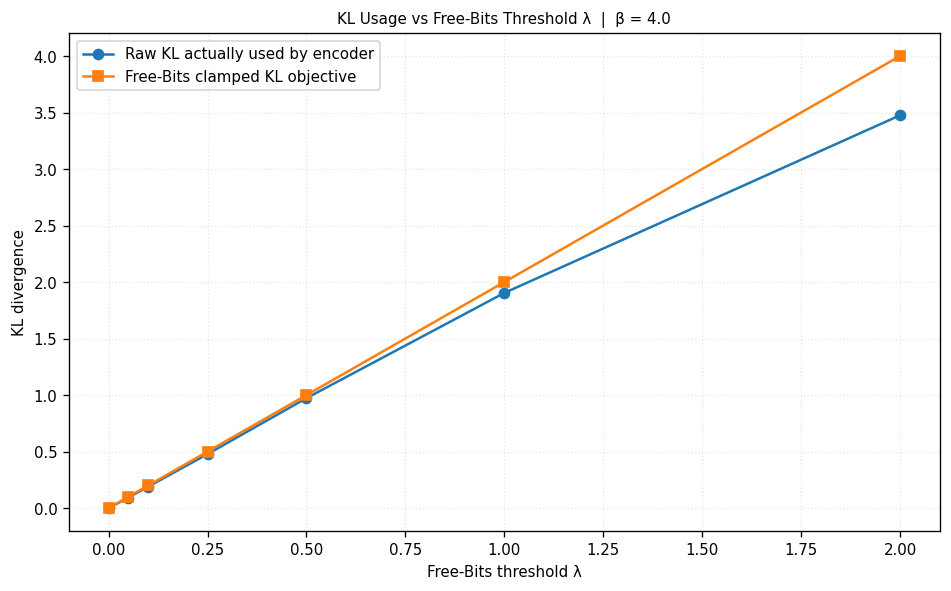

In [27]:
# ── Plot: KL vs Free-Bits threshold λ ─────────────────────────────────────────

lambda_vals = np.array(lambdas_fb)
raw_kl_vals = np.array([metrics_lambda_fb[lam]["raw_kl"] for lam in lambdas_fb])
fb_kl_vals  = np.array([metrics_lambda_fb[lam]["fb_kl"] for lam in lambdas_fb])

plt.figure(figsize=(8, 5))

plt.plot(lambda_vals, raw_kl_vals, marker='o', label='Raw KL actually used by encoder')
plt.plot(lambda_vals, fb_kl_vals, marker='s', label='Free-Bits clamped KL objective')

plt.xlabel('Free-Bits threshold λ')
plt.ylabel('KL divergence')
plt.title(f'KL Usage vs Free-Bits Threshold λ  |  β = {beta_lambda}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig('plot_FB_KL_vs_lambda.png', bbox_inches='tight', dpi=150)
plt.show()

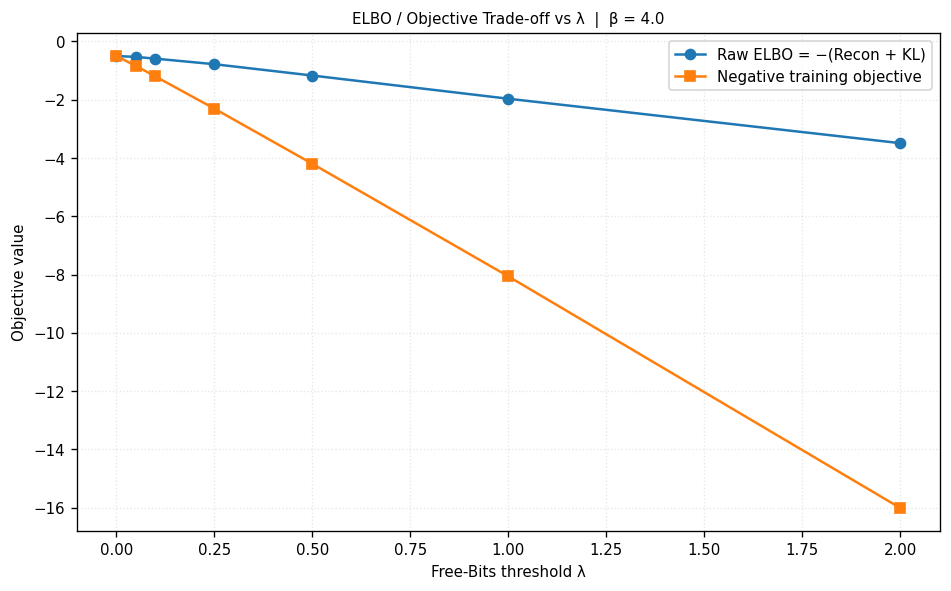

In [28]:
# ── Plot: ELBO vs Free-Bits threshold λ ───────────────────────────────────────

elbo_vals = np.array([metrics_lambda_fb[lam]["elbo_raw"] for lam in lambdas_fb])
obj_vals  = np.array([metrics_lambda_fb[lam]["objective_fb"] for lam in lambdas_fb])

plt.figure(figsize=(8, 5))

plt.plot(lambda_vals, elbo_vals, marker='o', label='Raw ELBO = −(Recon + KL)')
plt.plot(lambda_vals, -obj_vals, marker='s', label='Negative training objective')

plt.xlabel('Free-Bits threshold λ')
plt.ylabel('Objective value')
plt.title(f'ELBO / Objective Trade-off vs λ  |  β = {beta_lambda}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig('plot_FB_ELBO_vs_lambda.png', bbox_inches='tight', dpi=150)
plt.show()

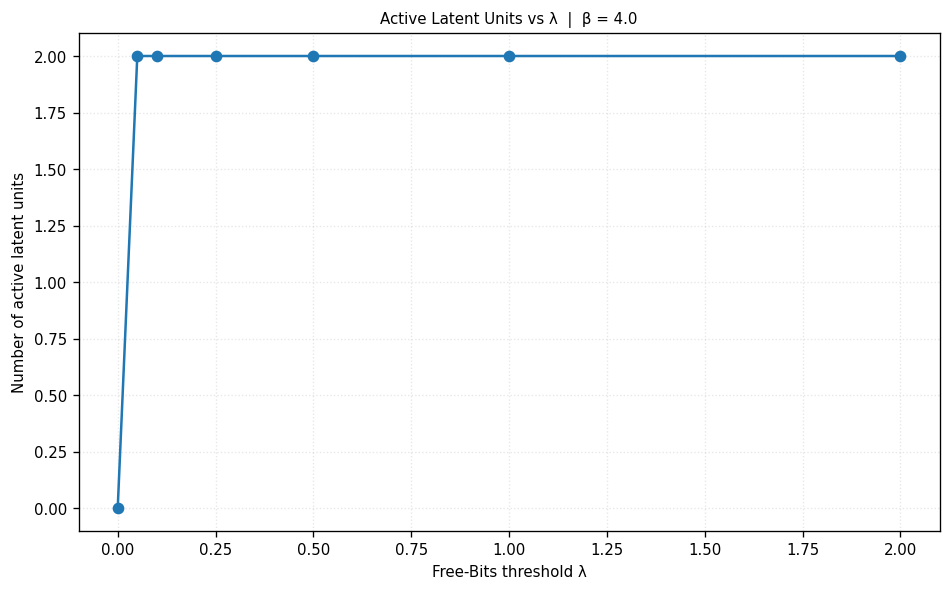

In [29]:
# ── Plot: Active latent units vs Free-Bits threshold λ ────────────────────────

active_vals = np.array([metrics_lambda_fb[lam]["active_units"] for lam in lambdas_fb])

plt.figure(figsize=(8, 5))

plt.plot(lambda_vals, active_vals, marker='o')

plt.xlabel('Free-Bits threshold λ')
plt.ylabel('Number of active latent units')
plt.title(f'Active Latent Units vs λ  |  β = {beta_lambda}')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('plot_FB_active_units_vs_lambda.png', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# ── Summary table for λ-sweep ─────────────────────────────────────────────────

print(
    f"{'λ':>6} │ {'MSE':>10} │ {'Raw KL':>10} │ {'FB KL':>10} │ "
    f"{'ELBO raw':>12} │ {'Active units':>13}"
)
print("─" * 75)

for lam in lambdas_fb:
    m = metrics_lambda_fb[lam]

    print(
        f"{lam:>6.2f} │ "
        f"{m['recon_mse']:>10.5f} │ "
        f"{m['raw_kl']:>10.5f} │ "
        f"{m['fb_kl']:>10.5f} │ "
        f"{m['elbo_raw']:>12.5f} │ "
        f"{m['active_units']:>13}"
    )

     λ │        MSE │     Raw KL │      FB KL │     ELBO raw │  Active units
───────────────────────────────────────────────────────────────────────────
  0.00 │    0.50000 │    0.00000 │    0.00000 │     -0.50000 │             0
  0.05 │    0.43710 │    0.09332 │    0.10000 │     -0.53042 │             2
  0.10 │    0.40106 │    0.18985 │    0.20000 │     -0.59091 │             2
  0.25 │    0.30302 │    0.47783 │    0.50000 │     -0.78086 │             2
  0.50 │    0.19725 │    0.97265 │    1.00000 │     -1.16989 │             2
  1.00 │    0.06258 │    1.90387 │    2.00000 │     -1.96645 │             2
  2.00 │    0.01672 │    3.47524 │    4.00000 │     -3.49196 │             2
